Chapter 26
# 可视化成对距离矩阵下三角部分 (不含主对角线元素)
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import string
from scipy.spatial import distance_matrix

In [2]:
# 产生随机数
num = 26
np.random.seed(0) #种子
data = np.random.randint(10 + 1, size=(num, 2)) # 生成26个点
labels = list(string.ascii_uppercase)

In [3]:
# 计算成对距离矩阵
pairwise_ds = distance_matrix(data, data) # 26*26

In [6]:
pairwise_ds

array([[ 0.        ,  3.60555128,  9.21954446,  5.38516481,  5.        ,
         6.32455532,  8.54400375,  5.09901951,  7.07106781,  8.24621125,
         6.40312424,  8.94427191,  5.65685425,  2.        ,  5.38516481,
         5.38516481,  8.24621125,  5.        ,  3.60555128,  2.        ,
         9.8488578 ,  4.        ,  6.40312424,  3.60555128,  7.61577311,
         3.        ],
       [ 3.60555128,  0.        ,  7.21110255,  2.        ,  1.41421356,
         5.        ,  7.07106781,  7.28010989,  5.        ,  6.40312424,
         2.82842712,  7.81024968,  6.08276253,  3.        ,  2.        ,
         3.16227766,  5.        ,  2.        ,  0.        ,  5.        ,
         6.32455532,  6.70820393,  7.07106781,  4.        ,  4.12310563,
         3.16227766],
       [ 9.21954446,  7.21110255,  0.        ,  5.65685425,  7.07106781,
         3.        ,  1.41421356,  8.54400375,  2.23606798,  1.        ,
         7.21110255,  2.23606798,  5.38516481,  9.8488578 ,  5.65685425,
       

在生成成对距离矩阵之后，我们还生成了一个 (剔除主对角
线) 下三角矩阵的面具 (mask)。在鸢尾花书中，mask 一般被直译为面具，也常被翻译做蒙皮、掩
码、遮罩等等。

a
用了 NumPy 库中的函数来创建一个面具"mask"，用于过滤计算得到的"pairwise_ds"数组。
numpy.ones_like() 创建了一个与"pairwise_ds"数组形状相同的全为 1 的布尔类型数组。
"dtype=bool"指定数组元素的数据类型为布尔类型 (True 或 False)，所有元素都被设置为
True。numpy.triu() 函数的"triu"代表"triangle upper"，它是"numpy"库中的函数，用于
获取矩阵的上三角部分 (包括对角线)，而将下三角部分设置为 0。

In [8]:
# 产生蒙皮/面具
mask = np.triu(np.ones_like(pairwise_ds, dtype=bool))

In [9]:
mask

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  

如
b
所示，使用 seaborn.heatmap 绘制热图时，mask 中对应位置为 True 的单元格的成对距
离矩阵数据将不会被显示

<Axes: >

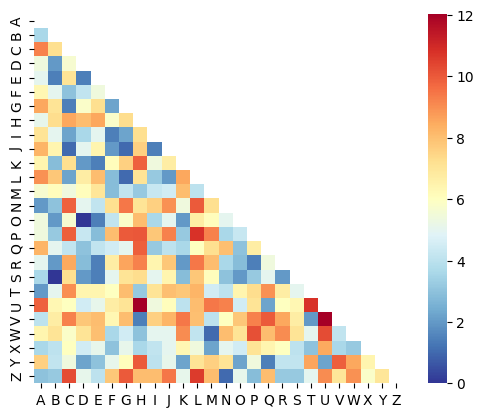

In [10]:
fig, ax = plt.subplots()
sns.heatmap(pairwise_ds,
            mask = mask, #mask 中对应位置为 True 的单元格的成对距离矩阵数据将不会被显示。

            cmap = 'RdYlBu_r',
            square = True,
            xticklabels = labels,
            yticklabels = labels,
            ax = ax)
# fig.savefig('下三角.svg', format='svg')

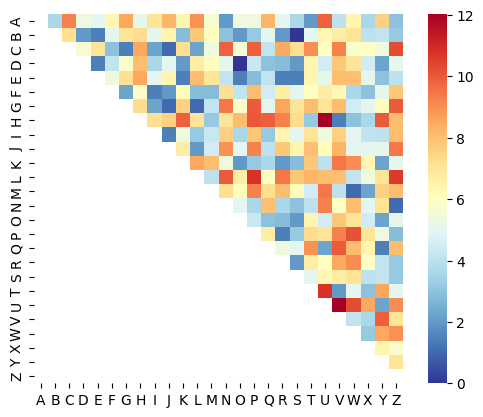

In [11]:
mask = np.tril(np.ones_like(pairwise_ds, dtype=bool)) # 下三角为true
fig, ax = plt.subplots()
sns.heatmap(pairwise_ds,
 mask = mask, #mask 中对应位置为 True 的单元格的成对距离矩阵数据将不会被显示。
 cmap = 'RdYlBu_r',
 square = True,
 xticklabels = labels,
 yticklabels = labels,
 ax = ax)
fig.savefig('上三角.svg', format='svg')